In [ ]:
import importlib
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score, classification_report

sys.path.insert(0, '.')
import absa_v2 as absa
importlib.reload(absa)

print(f'absa_v2.py 로드 완료. 속성 수: {len(absa.ASPECTS)}')

In [ ]:

# %% [markdown]
# ─────────────────────────────────────────────────────────────────────
# ## Phase B-1. Gate 1: Cross-Overlap κ 측정
#
# **선행**: `송원우/final_data/absa_overlap_validation_L1_DONE.xlsx` 저장 완료
# (Phase A — 100건 라벨링 완료 후 파일명 변경하여 저장)

# %%
DONE_PATH = 'absa_overlap_validation_L1.xlsx'
ANS_PATH  = '_overlap_answer_key_v23_DO_NOT_OPEN_BEFORE_LABELING.xlsx'

l1 = pd.read_excel(DONE_PATH, sheet_name='1_검증라벨링', header=1)
ans = pd.read_excel(ANS_PATH)

# 채움 검증
fn_done = l1['기능성_라벨러1'].notna().sum()
br_done = l1['브랜드_라벨러1'].notna().sum()
print(f'기능성 채움: {fn_done}/100')
print(f'브랜드 채움: {br_done}/100')
assert fn_done == 100 and br_done == 100, '미라벨링 행 존재 — Phase A 미완료'

# 병합
m = l1.merge(ans, on='sample_idx')
print(f'병합 결과: {len(m)}건')

# %%
def report_kappa(a, b, name):
    a, b = a.astype(str), b.astype(str)
    k = cohen_kappa_score(a, b)
    agree = int((a == b).sum())
    grade = ('Almost Perfect' if k >= 0.81 else
             'Substantial'    if k >= 0.61 else
             'Moderate'       if k >= 0.41 else 'Fair/Slight')
    print(f'\n[{name}]  κ = {k:.4f}  ({grade})  일치 {agree}/{len(a)}')
    print(pd.crosstab(a, b, rownames=['L1'], colnames=['L2(v23)'], margins=True))
    print(classification_report(b, a, digits=3, zero_division=0))
    return k

print('═' * 60)
print('  Gate 1 — Cross-Overlap κ')
print('═' * 60)
k_fn = report_kappa(m['기능성_라벨러1'],  m['기능성_L2(v23)'],   '기능성')
k_br = report_kappa(m['브랜드_라벨러1'],  m['브랜드_L2(v23)'],   '브랜드/헤리티지')

macro = float(np.mean([k_fn, k_br]))
print(f'\n>> Macro κ = {macro:.4f}')
print('>> 판정:')
if macro >= 0.81:
    verdict = '✅ Almost Perfect — Phase C 즉시 진입'
elif macro >= 0.65:
    verdict = '✅ Substantial — Phase C 진입'
elif macro >= 0.50:
    verdict = '⚠️ Moderate — 불일치 분석 후 송원우 합의 미팅'
else:
    verdict = '❌ 미달 — 가이드라인 v2.3 patch 필수, Phase C 진입 금지'
print(f'   {verdict}')

In [ ]:
# ## Phase B-2. 불일치 케이스 추출 (κ < 0.65 시)

# %%
mismatch_fn = m[m['기능성_라벨러1'] != m['기능성_L2(v23)']][[
    'sample_idx', 'brand', 'rating', 'content_clean',
    '기능성_라벨러1', '기능성_L2(v23)', '메모',
]]
mismatch_br = m[m['브랜드_라벨러1'] != m['브랜드_L2(v23)']][[
    'sample_idx', 'brand', 'rating', 'content_clean',
    '브랜드_라벨러1', '브랜드_L2(v23)', '메모',
]]

print(f'기능성 불일치: {len(mismatch_fn)}건')
print(f'브랜드 불일치: {len(mismatch_br)}건')

with pd.ExcelWriter('overlap_mismatch.xlsx') as w:
    mismatch_fn.to_excel(w, sheet_name='기능성_불일치', index=False)
    mismatch_br.to_excel(w, sheet_name='브랜드_불일치', index=False)
print('✓ 저장: overlap_mismatch.xlsx')

In [ ]:
importlib.reload(absa)

golden = absa.load_golden_set()
print(f'골든셋: {len(golden)}건')

# Stage1 트리거 매칭 스모크 테스트
sample_content = golden.iloc[0]['content_clean']
s1 = absa.stage1_trigger_match(sample_content)
print(f'샘플 리뷰: {sample_content[:80]}...')
print(f'Stage1 결과: {s1}')

In [ ]:
# ## Phase C-2. Few-shot 빌드 (라벨러1 구현 후 실행)

# %%
# [L1 구현 완료 후 실행]
few_shots = absa.build_few_shot_examples(golden, n_per_class=3)
for aspect, examples in few_shots.items():
    print(f'\n[{aspect}] Few-shot {len(examples)}건')
    for content, label in examples[:3]:
        print(f'  ({label}) {content[:60]}...')

In [ ]:
# ## Phase C-3. 골든셋 분할 (학습/검증)

# %%
# Few-shot pool: 속성별 P/N/X 각 5건 = sample_idx 추출
# 나머지 ~910건이 검증용

# few_shots의 content 문자열 → golden의 sample_idx 역매핑
few_shot_contents = {content for examples in few_shots.values() for content, _ in examples}
few_shot_idxs = golden.loc[golden['content_clean'].isin(few_shot_contents), 'sample_idx']

valid_mask = ~golden['sample_idx'].isin(few_shot_idxs)
valid = golden[valid_mask].reset_index(drop=True)
print(f'Few-shot 사용 샘플: {len(few_shot_idxs)}건')
print(f'검증 셋: {len(valid)}건')

## [v1 기록] absa.py — Gate 2 실패 (2025-05-07)

| 항목 | 내용 |
|------|------|
| 사용 파일 | `absa.py` (Stage1 트리거 → LLM 캐스케이드, per-aspect 6회 호출) |
| 검증셋 | 973건 (골든셋 1000건 중 few-shot 27건 제외) |
| **Macro-F1** | **0.4162** — Gate 2 기준 0.70 미달 ❌ |
| 추론 속도 | 약 28초/건 |

### 속성별 F1

| 속성 | F1 | 판정 |
|------|----|------|
| 핏/사이즈 | 0.4376 | ❌ |
| 소재/내구성 | 0.3887 | ❌ |
| 기능성 | 0.2810 | ❌ |
| 디자인 | 0.4427 | ❌ |
| 브랜드/헤리티지 | 0.5138 | ⚠️ (유일하게 상대적으로 높음) |
| 가격/가치 | 0.4337 | ❌ |

### Confusion Matrix & Classification Report

**[핏/사이즈]**
```
pred   N   P    X  All
N     54   0  172  226
P      4  57  270  331
X      6   0  410  416

P: precision=1.000  recall=0.172  f1=0.294
N: precision=0.844  recall=0.239  f1=0.372
X: precision=0.481  recall=0.986  f1=0.647
accuracy=0.535  macro avg F1=0.438
```

**[소재/내구성]**
```
pred   N   P    X  All
N     20   1  148  169
P      7  36  228  271
X      5   1  527  533

P: precision=0.947  recall=0.133  f1=0.233
N: precision=0.625  recall=0.118  f1=0.199
X: precision=0.584  recall=0.989  f1=0.734
accuracy=0.599  macro avg F1=0.389
```

**[기능성]**
```
pred   N   P    X  All
N      5   0  109  114
P      2  24  378  404
X      2   0  453  455

P: precision=1.000  recall=0.059  f1=0.112
N: precision=0.556  recall=0.044  f1=0.081
X: precision=0.482  recall=0.996  f1=0.649
accuracy=0.495  macro avg F1=0.281
```

**[디자인]**
```
pred   N    P    X  All
N      9    0   58   67
P      3   98  313  414
X      1    3  488  492

P: precision=0.970  recall=0.237  f1=0.381
N: precision=0.692  recall=0.134  f1=0.225
X: precision=0.568  recall=0.992  f1=0.722
accuracy=0.612  macro avg F1=0.443
```

**[브랜드/헤리티지]**
```
pred   N   P    X  All
N     28   0   75  103
P      2  36  160  198
X      6   8  658  672

P: precision=0.818  recall=0.182  f1=0.298
N: precision=0.778  recall=0.272  f1=0.403
X: precision=0.737  recall=0.979  f1=0.841
accuracy=0.742  macro avg F1=0.514
```

**[가격/가치]**
```
pred   N  P    X  All
N      2  0   34   36
P      0  6   39   45
X      0  0  892  892

P: precision=1.000  recall=0.133  f1=0.235
N: precision=1.000  recall=0.056  f1=0.105
X: precision=0.924  recall=1.000  f1=0.961
accuracy=0.925  macro avg F1=0.434
```

### 실패 원인 분석

**핵심 원인: `predict_one()` 내 Stage1 X ショートカット**

```python
# absa.py predict_one() 문제 코드
if label == 'X':
    out[aspect] = 'X'  # ← Stage1이 X이면 LLM 미호출
```

트리거 키워드가 형태소 변화형을 커버하지 못함 (예: `예쁘` → `예뻐요` 미매칭, `부드럽` → `부드러워요` 미매칭).
결과적으로 85~99% 리뷰가 Stage1에서 X로 판정되어 LLM 없이 그대로 X 출력 → P/N recall 극히 낮음.

모든 속성에서 X recall이 0.98~1.00인 반면 P/N recall이 0.04~0.24로 붕괴된 패턴이 이를 증명.

### 대응

`absa_v2.py` 신규 생성:
- Stage1 X 숏컷 제거 → LLM이 모든 P/N/X 판단
- 6속성 배치 호출(1회) → 속도 약 3~4배 개선 (28초 → 7~8초/건)
- 50건마다 체크포인트 저장 → 중단 후 재실행 시 이어받기

In [ ]:
## Phase D. Gate 2: 모델 검증 — 이 셀 단독으로 맨 밑에서 바로 실행 가능
# [v2-배치] 6속성을 LLM 1회 호출로 처리 → v2-개별(7시간) 대비 약 3~4배 빠름.
# 위 셀(Phase B/C)을 실행하지 않아도 자동으로 필요한 변수를 재구성합니다.
# 중간에 중단돼도 absa_val_checkpoint_batch.csv에서 이어받기 합니다.

import importlib, sys
import numpy as np
import pandas as pd
sys.path.insert(0, '.')
import absa_v2 as absa
importlib.reload(absa)

CHECKPOINT = 'absa_val_checkpoint_batch.csv'  # 50건마다 자동 저장

# ── 선행 변수 복구 ─────────────────────────────────────────────────
try:
    few_shots; valid
    print(f'기존 변수 사용 — 검증셋: {len(valid)}건')
except NameError:
    print('few_shots / valid 없음 → 골든셋에서 재구성 중...')
    golden = absa.load_golden_set()
    few_shots = absa.build_few_shot_examples(golden, n_per_class=3)
    few_shot_contents = {c for exs in few_shots.values() for c, _ in exs}
    few_shot_idxs = golden.loc[golden['content_clean'].isin(few_shot_contents), 'sample_idx']
    valid = golden[~golden['sample_idx'].isin(few_shot_idxs)].reset_index(drop=True)
    print(f'재구성 완료 — 검증셋: {len(valid)}건')

# ── 추론 (배치 모드 + 체크포인트 지원) ───────────────────────────────
pred = absa.predict_dataframe(valid, few_shots, checkpoint_path=CHECKPOINT)
pred.to_csv('absa_predictions_validation.csv', index=False)
print('✓ 저장 완료: absa_predictions_validation.csv')

# ── 평가 ──────────────────────────────────────────────────────────
eval_result = absa.evaluate(pred, valid)
absa.print_evaluation_report(eval_result)

# Gate 2 판정
if eval_result['macro_f1'] >= 0.70:
    print('\n✅ Gate 2 통과 → Phase E 진입')
else:
    low = absa.diagnose_low_f1_aspect(eval_result, threshold=0.60)
    print(f'\n⚠️ Gate 2 미달. F1 < 0.60 속성: {low}')
    print('→ Few-shot 3→5건 보강 또는 트리거 사전 보강 후 재실행')

In [ ]:
# ── 평가만 재실행 (추론 결과가 이미 저장돼 있을 때) ──────────────────
# 위 셀에서 추론이 완료된 후, 평가 결과만 다시 보고 싶을 때 이 셀만 실행.
# pred = pd.read_csv('absa_predictions_validation.csv')
# eval_result = absa.evaluate(pred, valid)
# absa.print_evaluation_report(eval_result)

## [v2 기록] absa_v2.py — Gate 2 미달 (2025-05-07)

| 항목 | 내용 |
|------|------|
| 사용 파일 | `absa_v2.py` (LLM 전량 판단 + 6속성 배치 1회 호출) |
| 검증셋 | 973건 |
| **Macro-F1** | **0.6474** — Gate 2 기준 0.70 미달 ❌ |
| 추론 속도 | 약 7.7초/건 (v1 대비 3.6배 개선) |

### 속성별 F1

| 속성 | F1 | 판정 |
|------|----|------|
| 핏/사이즈 | 0.6650 | ✅ |
| 소재/내구성 | 0.6609 | ✅ |
| 기능성 | 0.7072 | ✅ |
| 디자인 | 0.7184 | ✅ |
| **브랜드/헤리티지** | **0.4021** | **❌ 주범** |
| 가격/가치 | 0.7309 | ✅ |

### 실패 원인 분석

브랜드/헤리티지 단독 실패. 973건 중 931건(95.7%)을 X로 예측 (골드 기준 X는 672건, 69%).

- P gold 198건 → 모델 P 예측 15건 (recall=0.076)
- N gold 103건 → 모델 N 예측 15건 (recall=0.146)

**원인**: 배치 프롬프트에 브랜드/헤리티지 판단 기준이 없어 LLM이 불확실하면 X로 도망.
TRIGGERS에 '재구매·추천' 등 좁은 키워드만 있어 '안다르답', '강추', '여기만' 등 다수 표현 미커버.

### 대응

`absa_v3.py` 신규 생성:
- TRIGGERS_P/N을 `absa_relabel.py` v2.2 기준으로 전면 교체 (브랜드/헤리티지 키워드 대폭 보강)
- 배치 프롬프트에 브랜드/헤리티지 판단 기준 명시
- `apply_trigger_correction()`: LLM=X이고 트리거 매칭 시 P/N으로 후보정
- `build_batch_examples()`: 브랜드/헤리티지 P/N 예시 최소 1건 강제 포함

In [ ]:
## Phase D-v3. Gate 2: 모델 검증 — 이 셀 단독으로 맨 밑에서 바로 실행 가능
# [v3] absa_relabel.py 트리거 적용 + 브랜드/헤리티지 후보정
# v2 대비: TRIGGERS 전면 교체 + 배치 프롬프트 브랜드 기준 명시 + LLM=X 시 트리거로 후보정

import importlib, sys
import numpy as np
import pandas as pd
sys.path.insert(0, '.')
import absa_v3 as absa
importlib.reload(absa)

CHECKPOINT = 'absa_val_checkpoint_v3.csv'  # 50건마다 자동 저장

# ── 선행 변수 복구 ─────────────────────────────────────────────────
try:
    few_shots; valid
    print(f'기존 변수 사용 — 검증셋: {len(valid)}건')
except NameError:
    print('few_shots / valid 없음 → 골든셋에서 재구성 중...')
    golden = absa.load_golden_set()
    few_shots = absa.build_few_shot_examples(golden, n_per_class=3)
    few_shot_contents = {c for exs in few_shots.values() for c, _ in exs}
    few_shot_idxs = golden.loc[golden['content_clean'].isin(few_shot_contents), 'sample_idx']
    valid = golden[~golden['sample_idx'].isin(few_shot_idxs)].reset_index(drop=True)
    print(f'재구성 완료 — 검증셋: {len(valid)}건')

# ── 추론 (v3-배치+보정 + 체크포인트 지원) ─────────────────────────────
pred = absa.predict_dataframe(valid, few_shots, checkpoint_path=CHECKPOINT)
pred.to_csv('absa_predictions_v3.csv', index=False)
print('✓ 저장 완료: absa_predictions_v3.csv')

# ── 평가 ──────────────────────────────────────────────────────────
eval_result = absa.evaluate(pred, valid)
absa.print_evaluation_report(eval_result)

# Gate 2 판정
if eval_result['macro_f1'] >= 0.70:
    print('\n✅ Gate 2 통과 → Phase E 진입')
else:
    low = absa.diagnose_low_f1_aspect(eval_result, threshold=0.60)
    print(f'\n⚠️ Gate 2 미달. F1 < 0.60 속성: {low}')
    print('→ few-shot 보강 또는 트리거 추가 후 재실행')

In [ ]:
## Phase D-v4. Gate 2 검증
import importlib, sys
import pandas as pd
sys.path.insert(0, '.')
import absa_v4 as absa
importlib.reload(absa)

CHECKPOINT = 'absa_val_checkpoint_v4.csv'

try:
    few_shots; valid
    print(f'기존 변수 사용 — 검증셋: {len(valid)}건')
except NameError:
    golden = absa.load_golden_set()          # tokens 없으면 자동 생성
    few_shots = absa.build_few_shot_examples(golden, n_per_class=3)
    few_shot_contents = {c for exs in few_shots.values() for c, _ in exs}
    few_shot_idxs = golden.loc[golden['content_clean'].isin(few_shot_contents), 'sample_idx']
    valid = golden[~golden['sample_idx'].isin(few_shot_idxs)].reset_index(drop=True)
    print(f'재구성 완료 — 검증셋: {len(valid)}건')

pred = absa.predict_dataframe(valid, few_shots, checkpoint_path=CHECKPOINT)
pred.to_csv('absa_predictions_v4.csv', index=False)

eval_result = absa.evaluate(pred, valid)
absa.print_evaluation_report(eval_result)

if eval_result['macro_f1'] >= 0.70:
    print('\n✅ Gate 2 통과 → Phase E 진입')
else:
    low = absa.diagnose_low_f1_aspect(eval_result, threshold=0.60)
    print(f'\n⚠️ Gate 2 미달. F1 < 0.60 속성: {low}')


In [ ]:
## Phase D-v5. Gate 2 검증
import importlib, sys
import pandas as pd
sys.path.insert(0, '.')
import absa_v5 as absa
importlib.reload(absa)

CHECKPOINT = 'absa_val_checkpoint_v5.csv'

try:
    few_shots; valid
    print(f'기존 변수 사용 — 검증셋: {len(valid)}건')
except NameError:
    golden = absa.load_golden_set()
    few_shots = absa.build_few_shot_examples(golden, n_per_class=3)
    few_shot_contents = {c for exs in few_shots.values() for c, _ in exs}
    few_shot_idxs = golden.loc[golden['content_clean'].isin(few_shot_contents), 'sample_idx']
    valid = golden[~golden['sample_idx'].isin(few_shot_idxs)].reset_index(drop=True)
    print(f'재구성 완료 — 검증셋: {len(valid)}건')

pred = absa.predict_dataframe(valid, few_shots, checkpoint_path=CHECKPOINT)
pred.to_csv('absa_predictions_v5.csv', index=False)
eval_result = absa.evaluate(pred, valid)
absa.print_evaluation_report(eval_result)

if eval_result['macro_f1'] >= 0.70:
    print('\n✅ Gate 2 통과 → Phase E 진입')
else:
    low = absa.diagnose_low_f1_aspect(eval_result, threshold=0.60)
    print(f'\n⚠️ Gate 2 미달. F1 < 0.60 속성: {low}')

In [1]:
import importlib, sys
sys.path.insert(0, '.')
import absa_v6 as absa
importlib.reload(absa)
import pandas as pd

golden = absa.load_golden_set('absa_golden_set_1000_v23.xlsx')

# v6 few-shot: build_batch_examples 기준으로 제외
batch_examples = absa.build_batch_examples(golden, n_examples=8)
batch_idxs = set()
for content, labels in batch_examples:
    match = golden[golden['content_clean'] == content]['sample_idx']
    if not match.empty:
        batch_idxs.add(int(match.iloc[0]))

valid = golden[~golden['sample_idx'].isin(batch_idxs)].reset_index(drop=True)
print(f'검증셋: {len(valid)}건  (few-shot 제외: {len(batch_idxs)}건)')

pred_v6 = absa.predict_dataframe(
    valid,
    few_shots={},
    checkpoint_path='absa_val_checkpoint_v6.csv',
    golden_path='absa_golden_set_1000_v23.xlsx',
    workers=2,
)
pred_v6.to_csv('absa_predictions_v6.csv', index=False)
print('저장 완료')

eval_v6 = absa.evaluate(pred_v6, valid)
absa.print_evaluation_report(eval_v6)

macro = eval_v6['macro_f1']
if macro >= 0.70:
    print(f'\n✅ Gate 2 통과! Macro-F1={macro:.4f}')
else:
    low = absa.diagnose_low_f1_aspect(eval_v6, threshold=0.60)
    print(f'\n⚠️  미달 (F1={macro:.4f}). F1 < 0.60 속성: {low}')


[v6] tokens 컬럼 없음 → KiWi 토크나이저로 자동 생성 중...
  완료: 1000건
검증셋: 992건  (few-shot 제외: 8건)
[v6] tokens 컬럼 없음 → KiWi 토크나이저로 자동 생성 중...
  완료: 1000건


추론(v6-핏보정OFF): 100%|██████████| 992/992 [2:17:14<00:00,  8.30s/it]  


저장 완료
════════════════════════════════════════════════════════════
  Macro-F1: 0.6343
════════════════════════════════════════════════════════════
  ❌ 핏/사이즈          F1=0.4445
  ✅ 소재/내구성         F1=0.7376
  ✅ 기능성            F1=0.6759
  ✅ 디자인            F1=0.6362
  ✅ 브랜드/헤리티지       F1=0.6344
  ✅ 가격/가치          F1=0.6769


[핏/사이즈] Confusion Matrix:
pred    N    P   X  All
gold                   
N     145   86   0  231
P       3  330   2  335
X     100  303  23  426
All   248  719  25  992

[핏/사이즈] Classification Report:
              precision    recall  f1-score   support

           P      0.459     0.985     0.626       335
           N      0.585     0.628     0.605       231
           X      0.920     0.054     0.102       426

    accuracy                          0.502       992
   macro avg      0.655     0.556     0.445       992
weighted avg      0.686     0.502     0.396       992


[소재/내구성] Confusion Matrix:
pred    N    P    X  All
gold                    
N     105   16  

In [1]:
import importlib, sys
sys.path.insert(0, '.')
import absa_v7 as absa
importlib.reload(absa)
import pandas as pd

golden = absa.load_golden_set('absa_golden_set_1000_v23.xlsx')

# v5와 동일하게 27건 제외 → 973건 검증셋
few_shots = absa.build_few_shot_examples(golden, n_per_class=3)
few_shot_idxs = set()
for examples in few_shots.values():
    for content, label in examples:
        match = golden[golden['content_clean'] == content]['sample_idx']
        if not match.empty:
            few_shot_idxs.add(int(match.iloc[0]))

valid = golden[~golden['sample_idx'].isin(few_shot_idxs)].reset_index(drop=True)
print(f'검증셋: {len(valid)}건  (제외: {len(few_shot_idxs)}건)')

pred_v7 = absa.predict_dataframe(
    valid, few_shots={},
    checkpoint_path='absa_val_checkpoint_v7.csv',
    golden_path='absa_golden_set_1000_v23.xlsx',
    workers=2,
)
pred_v7.to_csv('absa_predictions_v7.csv', index=False)

eval_v7 = absa.evaluate(pred_v7, valid)
absa.print_evaluation_report(eval_v7)

macro = eval_v7['macro_f1']
if macro >= 0.70:
    print(f'\n✅ Gate 2 통과! Macro-F1={macro:.4f}')
else:
    low = absa.diagnose_low_f1_aspect(eval_v7, threshold=0.60)
    print(f'\n⚠️  미달 (F1={macro:.4f}). F1 < 0.60 속성: {low}')


[v5] tokens 컬럼 없음 → KiWi 토크나이저로 자동 생성 중...
  완료: 1000건
검증셋: 973건  (제외: 27건)
[v5] tokens 컬럼 없음 → KiWi 토크나이저로 자동 생성 중...
  완료: 1000건


추론(v7-프롬프트규칙강화): 100%|██████████| 973/973 [2:03:10<00:00,  7.60s/it]  


════════════════════════════════════════════════════════════
  Macro-F1: 0.6903
════════════════════════════════════════════════════════════
  ✅ 핏/사이즈          F1=0.6042
  ✅ 소재/내구성         F1=0.7782
  ✅ 기능성            F1=0.7369
  ✅ 디자인            F1=0.7260
  ⚠️  브랜드/헤리티지       F1=0.5809
  ✅ 가격/가치          F1=0.7154


[핏/사이즈] Confusion Matrix:
pred    N    P    X  All
gold                    
N     142   83    1  226
P       1  323    7  331
X      52  233  131  416
All   195  639  139  973

[핏/사이즈] Classification Report:
              precision    recall  f1-score   support

           P      0.505     0.976     0.666       331
           N      0.728     0.628     0.675       226
           X      0.942     0.315     0.472       416

    accuracy                          0.613       973
   macro avg      0.725     0.640     0.604       973
weighted avg      0.744     0.613     0.585       973


[소재/내구성] Confusion Matrix:
pred    N    P    X  All
gold                    
N     125   15

In [3]:
## Phase D-v8. Gate 2 검증
import importlib, sys
sys.path.insert(0, '.')
import absa_v8 as absa
importlib.reload(absa)
import pandas as pd

golden = absa.load_golden_set('absa_golden_set_1000_v23.xlsx')

few_shots = absa.build_few_shot_examples(golden, n_per_class=3)
few_shot_idxs = set()
for examples in few_shots.values():
    for content, label in examples:
        match = golden[golden['content_clean'] == content]['sample_idx']
        if not match.empty:
            few_shot_idxs.add(int(match.iloc[0]))

valid = golden[~golden['sample_idx'].isin(few_shot_idxs)].reset_index(drop=True)
print(f'검증셋: {len(valid)}건  (제외: {len(few_shot_idxs)}건)')

pred_v8 = absa.predict_dataframe(
    valid, few_shots={},
    checkpoint_path='absa_val_checkpoint_v8.csv',
    golden_path='absa_golden_set_1000_v23.xlsx',
    workers=2,
)
pred_v8.to_csv('absa_predictions_v8.csv', index=False)

eval_v8 = absa.evaluate(pred_v8, valid)
absa.print_evaluation_report(eval_v8)

macro = eval_v8['macro_f1']
if macro >= 0.70:
    print(f'\n✅ Gate 2 통과! Macro-F1={macro:.4f}')
else:
    low = absa.diagnose_low_f1_aspect(eval_v8, threshold=0.60)
    print(f'\n⚠️  미달 (F1={macro:.4f}). F1 < 0.60 속성: {low}')


[v5] tokens 컬럼 없음 → KiWi 토크나이저로 자동 생성 중...
  완료: 1000건
검증셋: 973건  (제외: 27건)
[v5] tokens 컬럼 없음 → KiWi 토크나이저로 자동 생성 중...
  완료: 1000건


추론(v8-브랜드규칙완화): 100%|██████████| 973/973 [2:12:56<00:00,  8.20s/it]  


════════════════════════════════════════════════════════════
  Macro-F1: 0.7017
════════════════════════════════════════════════════════════
  ⚠️  핏/사이즈          F1=0.5831
  ✅ 소재/내구성         F1=0.7943
  ✅ 기능성            F1=0.7346
  ✅ 디자인            F1=0.7544
  ✅ 브랜드/헤리티지       F1=0.6022
  ✅ 가격/가치          F1=0.7418


[핏/사이즈] Confusion Matrix:
pred    N    P    X  All
gold                    
N     143   82    1  226
P       1  328    2  331
X      52  255  109  416
All   196  665  112  973

[핏/사이즈] Classification Report:
              precision    recall  f1-score   support

           P      0.493     0.991     0.659       331
           N      0.730     0.633     0.678       226
           X      0.973     0.262     0.413       416

    accuracy                          0.596       973
   macro avg      0.732     0.629     0.583       973
weighted avg      0.753     0.596     0.558       973


[소재/내구성] Confusion Matrix:
pred    N    P    X  All
gold                    
N     127   10

# 원우님 여기서부터 보시면 됩니다

## 추론 모델링

In [4]:
## Phase D-v9. Gate 2 검증
import importlib, sys
sys.path.insert(0, '.')
import absa_v9 as absa
importlib.reload(absa)
import pandas as pd

golden = absa.load_golden_set('absa_golden_set_1000_v23.xlsx')

few_shots = absa.build_few_shot_examples(golden, n_per_class=3)
few_shot_idxs = set()
for examples in few_shots.values():
    for content, label in examples:
        match = golden[golden['content_clean'] == content]['sample_idx']
        if not match.empty:
            few_shot_idxs.add(int(match.iloc[0]))

valid = golden[~golden['sample_idx'].isin(few_shot_idxs)].reset_index(drop=True)
print(f'검증셋: {len(valid)}건  (제외: {len(few_shot_idxs)}건)')

pred_v9 = absa.predict_dataframe(
    valid, few_shots={},
    checkpoint_path='absa_val_checkpoint_v9.csv',
    golden_path='absa_golden_set_1000_v23.xlsx',
    workers=2,
)
pred_v9.to_csv('absa_predictions_v9.csv', index=False)

eval_v9 = absa.evaluate(pred_v9, valid)
absa.print_evaluation_report(eval_v9)

macro = eval_v9['macro_f1']
if macro >= 0.70:
    print(f'\n✅ Gate 2 통과! Macro-F1={macro:.4f}')
else:
    low = absa.diagnose_low_f1_aspect(eval_v9, threshold=0.60)
    print(f'\n⚠️  미달 (F1={macro:.4f}). F1 < 0.60 속성: {low}')


[v5] tokens 컬럼 없음 → KiWi 토크나이저로 자동 생성 중...
  완료: 1000건
검증셋: 973건  (제외: 27건)
[v5] tokens 컬럼 없음 → KiWi 토크나이저로 자동 생성 중...
  완료: 1000건


추론(v9-핏규칙강화): 100%|██████████| 973/973 [2:19:48<00:00,  8.62s/it]  


════════════════════════════════════════════════════════════
  Macro-F1: 0.7032
════════════════════════════════════════════════════════════
  ✅ 핏/사이즈          F1=0.6107
  ✅ 소재/내구성         F1=0.7831
  ✅ 기능성            F1=0.7322
  ✅ 디자인            F1=0.7432
  ✅ 브랜드/헤리티지       F1=0.6019
  ✅ 가격/가치          F1=0.7478


[핏/사이즈] Confusion Matrix:
pred    N    P    X  All
gold                    
N     138   84    4  226
P       0  326    5  331
X      51  226  139  416
All   189  636  148  973

[핏/사이즈] Classification Report:
              precision    recall  f1-score   support

           P      0.513     0.985     0.674       331
           N      0.730     0.611     0.665       226
           X      0.939     0.334     0.493       416

    accuracy                          0.620       973
   macro avg      0.727     0.643     0.611       973
weighted avg      0.746     0.620     0.595       973


[소재/내구성] Confusion Matrix:
pred    N    P    X  All
gold                    
N     123   15  

## 데이터셋 분포

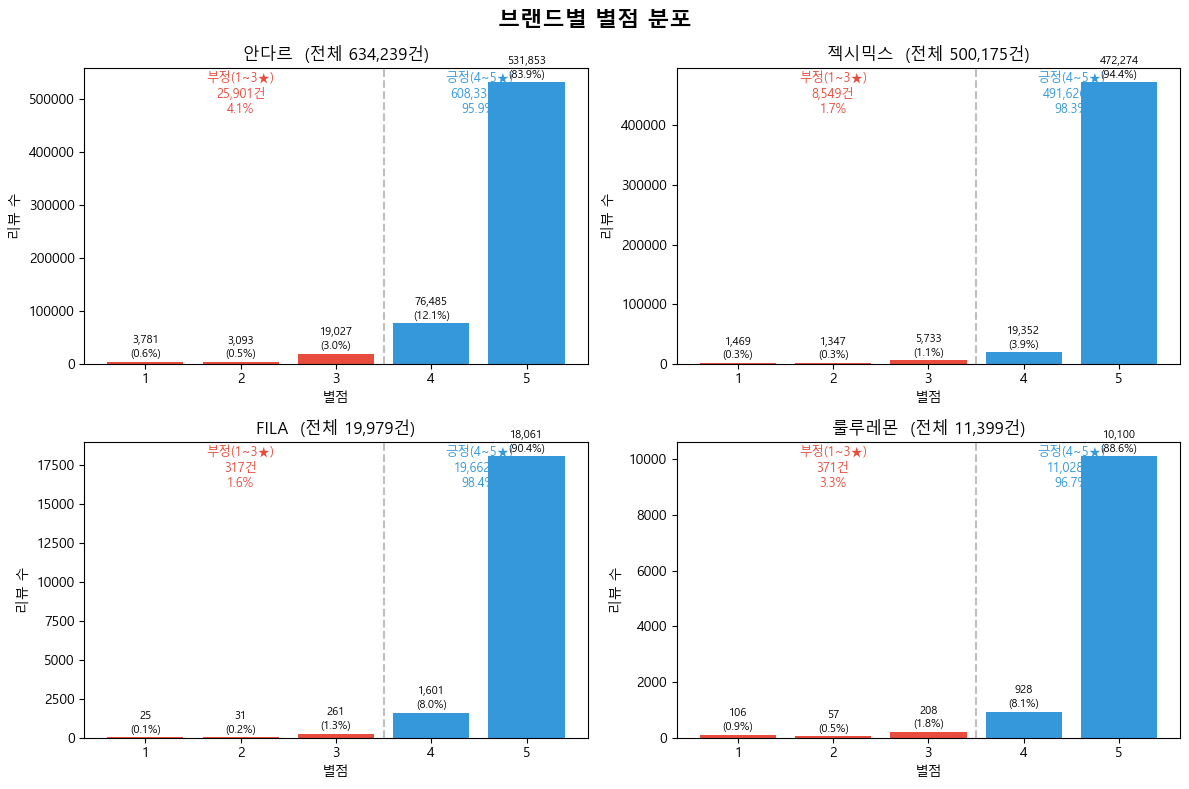

✓ 저장: brand_rating_distribution.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_parquet('data/preprocessed_absa.parquet')
df = df[df['rating'] != 0].copy()

brands = ['안다르', '젝시믹스', 'FILA', '룰루레몬']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('브랜드별 별점 분포', fontsize=16, fontweight='bold')

for ax, brand in zip(axes.flatten(), brands):
    bdf = df[df['brand'] == brand]
    counts = bdf['rating'].value_counts().sort_index()
    total = len(bdf)

    bars = ax.bar(counts.index, counts.values,
                  color=['#e74c3c' if r <= 3 else '#3498db' for r in counts.index])
    ax.set_title(f'{brand}  (전체 {total:,}건)', fontsize=12)
    ax.set_xlabel('별점')
    ax.set_ylabel('리뷰 수')
    ax.set_xticks([1, 2, 3, 4, 5])

    # 각 막대 위에 건수 + 비율 표시
    for bar, (rating, cnt) in zip(bars, counts.items()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
                f'{cnt:,}\n({cnt/total*100:.1f}%)',
                ha='center', va='bottom', fontsize=8)

    # 부정/긍정 구분선
    ax.axvline(x=3.5, color='gray', linestyle='--', alpha=0.5)
    neg = (bdf['rating'] <= 3).sum()
    pos = (bdf['rating'] >= 4).sum()
    ax.text(2, ax.get_ylim()[1]*0.85, f'부정(1~3★)\n{neg:,}건\n{neg/total*100:.1f}%',
            ha='center', color='#e74c3c', fontsize=9)
    ax.text(4.5, ax.get_ylim()[1]*0.85, f'긍정(4~5★)\n{pos:,}건\n{pos/total*100:.1f}%',
            ha='center', color='#3498db', fontsize=9)

plt.tight_layout()
plt.savefig('brand_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ 저장: brand_rating_distribution.png')


In [6]:
import pandas as pd

df = pd.read_parquet('data/preprocessed_absa.parquet')
df = df[df['rating'] != 0].copy()

print('=== 브랜드별 중복 리뷰 현황 (content_clean 기준) ===\n')
for brand in ['안다르', '젝시믹스', 'FILA', '룰루레몬']:
    bdf = df[df['brand'] == brand]
    total = len(bdf)
    unique = bdf['content_clean'].nunique()
    dup = total - unique
    print(f'{brand:8s}: 전체 {total:>7,}건  |  고유 {unique:>7,}건  |  중복 {dup:>6,}건 ({dup/total*100:.1f}%)')

print()
print('=== 전체 합계 ===')
total = len(df)
unique = df['content_clean'].nunique()
dup = total - unique
print(f'전체    : 전체 {total:>7,}건  |  고유 {unique:>7,}건  |  중복 {dup:>6,}건 ({dup/total*100:.1f}%)')

=== 브랜드별 중복 리뷰 현황 (content_clean 기준) ===

안다르     : 전체 634,239건  |  고유 624,050건  |  중복 10,189건 (1.6%)
젝시믹스    : 전체 500,175건  |  고유 477,075건  |  중복 23,100건 (4.6%)
FILA    : 전체  19,979건  |  고유  17,069건  |  중복  2,910건 (14.6%)
룰루레몬    : 전체  11,399건  |  고유  11,137건  |  중복    262건 (2.3%)

=== 전체 합계 ===
전체    : 전체 1,165,792건  |  고유 1,129,116건  |  중복 36,676건 (3.1%)


=== 중복 제거 후 브랜드별 현황 ===

안다르     : 전체 624,050건  |  부정 25,769건(4.1%)  긍정 598,281건(95.9%)
젝시믹스    : 전체 477,075건  |  부정 8,320건(1.7%)  긍정 468,755건(98.3%)
FILA    : 전체  17,069건  |  부정   274건(1.6%)  긍정  16,795건(98.4%)
룰루레몬    : 전체  11,137건  |  부정   371건(3.3%)  긍정  10,766건(96.7%)


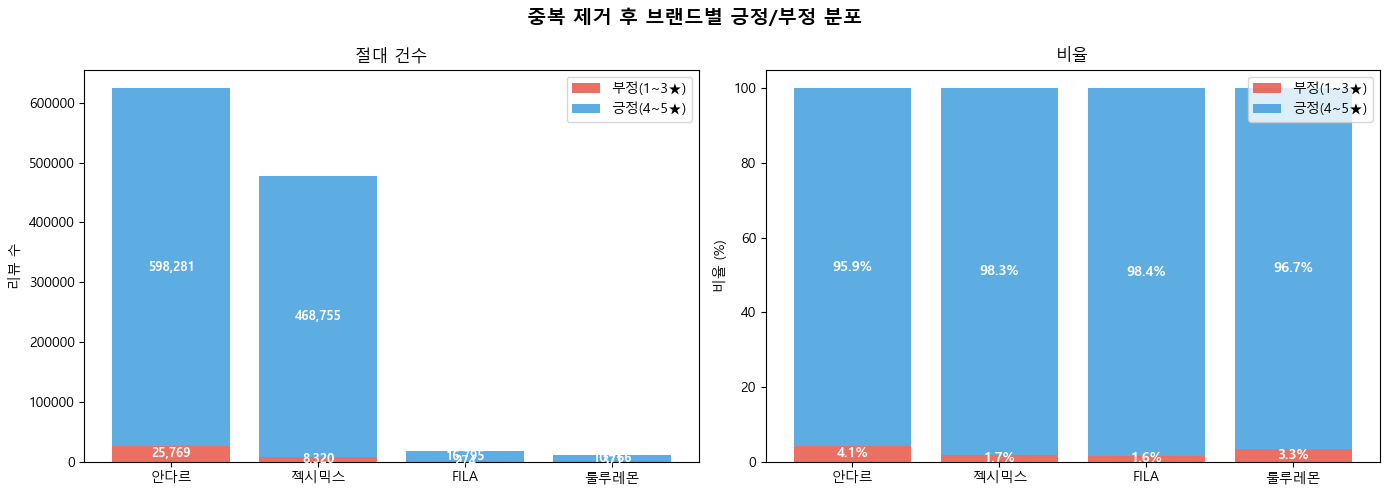

✓ 저장: brand_sentiment_distribution.png


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_parquet('data/preprocessed_absa.parquet')
df = df[df['rating'] != 0].copy()

# 중복 제거 (content_clean 기준, 각 브랜드 내에서)
df_dedup = df.drop_duplicates(subset=['brand', 'content_clean']).reset_index(drop=True)

# 긍정/부정 구분
df_dedup['sentiment'] = df_dedup['rating'].apply(lambda r: '긍정(4~5★)' if r >= 4 else '부정(1~3★)')

print('=== 중복 제거 후 브랜드별 현황 ===\n')
brands = ['안다르', '젝시믹스', 'FILA', '룰루레몬']
for brand in brands:
    bdf = df_dedup[df_dedup['brand'] == brand]
    total = len(bdf)
    neg = (bdf['rating'] <= 3).sum()
    pos = (bdf['rating'] >= 4).sum()
    print(f'{brand:8s}: 전체 {total:>7,}건  |  부정 {neg:>5,}건({neg/total*100:.1f}%)  긍정 {pos:>7,}건({pos/total*100:.1f}%)')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('중복 제거 후 브랜드별 긍정/부정 분포', fontsize=14, fontweight='bold')

# 왼쪽: 절대 건수 막대그래프
x = range(len(brands))
neg_counts = [len(df_dedup[(df_dedup['brand']==b) & (df_dedup['rating']<=3)]) for b in brands]
pos_counts = [len(df_dedup[(df_dedup['brand']==b) & (df_dedup['rating']>=4)]) for b in brands]

bars_neg = axes[0].bar(x, neg_counts, label='부정(1~3★)', color='#e74c3c', alpha=0.8)
bars_pos = axes[0].bar(x, pos_counts, bottom=neg_counts, label='긍정(4~5★)', color='#3498db', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(brands)
axes[0].set_ylabel('리뷰 수')
axes[0].set_title('절대 건수')
axes[0].legend()
for i, (n, p) in enumerate(zip(neg_counts, pos_counts)):
    axes[0].text(i, n/2, f'{n:,}', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    axes[0].text(i, n + p/2, f'{p:,}', ha='center', va='center', color='white', fontsize=9, fontweight='bold')

# 오른쪽: 비율 막대그래프
totals = [n+p for n,p in zip(neg_counts, pos_counts)]
neg_ratio = [n/t*100 for n,t in zip(neg_counts, totals)]
pos_ratio = [p/t*100 for p,t in zip(pos_counts, totals)]

axes[1].bar(x, neg_ratio, label='부정(1~3★)', color='#e74c3c', alpha=0.8)
axes[1].bar(x, pos_ratio, bottom=neg_ratio, label='긍정(4~5★)', color='#3498db', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(brands)
axes[1].set_ylabel('비율 (%)')
axes[1].set_title('비율')
axes[1].legend()
for i, (nr, pr) in enumerate(zip(neg_ratio, pos_ratio)):
    axes[1].text(i, nr/2, f'{nr:.1f}%', ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    axes[1].text(i, nr + pr/2, f'{pr:.1f}%', ha='center', va='center', color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('brand_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ 저장: brand_sentiment_distribution.png')


In [8]:
import pandas as pd

df = pd.read_parquet('data/preprocessed_absa.parquet')
df = df[df['rating'] != 0].copy()
df_dedup = df.drop_duplicates(subset=['brand', 'content_clean']).reset_index(drop=True)

brands = ['안다르', '젝시믹스', 'FILA', '룰루레몬']

print('=== 중복 제거 후 샘플링 가능 건수 ===\n')
for brand in brands:
    bdf = df_dedup[df_dedup['brand'] == brand]
    neg = (bdf['rating'] <= 3).sum()
    pos = (bdf['rating'] >= 4).sum()
    total = len(bdf)
    print(f'{brand:8s}: 부정 {neg:>5,}건  긍정 {pos:>7,}건  합계 {total:>7,}건')

print()
print('=== N_PER_BRAND별 추론 시간 및 부정 비율 한계 ===\n')
# 부정 한계: FILA·룰루레몬 기준
fila_neg  = len(df_dedup[(df_dedup['brand']=='FILA')    & (df_dedup['rating']<=3)])
lulu_neg  = len(df_dedup[(df_dedup['brand']=='룰루레몬') & (df_dedup['rating']<=3)])
bottleneck = min(fila_neg, lulu_neg)

print(f'  부정 리뷰 제약: FILA {fila_neg}건, 룰루레몬 {lulu_neg}건')
print(f'  → 부정 24% 비율 유지 가능 최대: {int(bottleneck/0.24):,}건/브랜드\n')

for n in [500, 1000, 2000, 3000, 5000]:
    total = n * 4
    hours = total * 8.6 / 3600
    neg_target = int(n * 0.24)
    fila_actual = min(fila_neg, neg_target)
    lulu_actual = min(lulu_neg, neg_target)
    flag = '✅' if neg_target <= bottleneck else '⚠️ 부정 고갈'
    print(f'  {n:>5,}건/브랜드 → 총 {total:,}건 / {hours:.1f}시간  |  부정목표 {neg_target}건  {flag}')


=== 중복 제거 후 샘플링 가능 건수 ===

안다르     : 부정 25,769건  긍정 598,281건  합계 624,050건
젝시믹스    : 부정 8,320건  긍정 468,755건  합계 477,075건
FILA    : 부정   274건  긍정  16,795건  합계  17,069건
룰루레몬    : 부정   371건  긍정  10,766건  합계  11,137건

=== N_PER_BRAND별 추론 시간 및 부정 비율 한계 ===

  부정 리뷰 제약: FILA 274건, 룰루레몬 371건
  → 부정 24% 비율 유지 가능 최대: 1,141건/브랜드

    500건/브랜드 → 총 2,000건 / 4.8시간  |  부정목표 120건  ✅
  1,000건/브랜드 → 총 4,000건 / 9.6시간  |  부정목표 240건  ✅
  2,000건/브랜드 → 총 8,000건 / 19.1시간  |  부정목표 480건  ⚠️ 부정 고갈
  3,000건/브랜드 → 총 12,000건 / 28.7시간  |  부정목표 720건  ⚠️ 부정 고갈
  5,000건/브랜드 → 총 20,000건 / 47.8시간  |  부정목표 1200건  ⚠️ 부정 고갈


## 추론 모델링에 사용할 샘플추출 코드

In [2]:
## Phase E-1. 속성 다양성 기반 층화 샘플링 (FILA 기준 1:10)
# 부정 274건(FILA 전수) + 긍정 2,740건(274×10) = 3,014건/브랜드 × 4브랜드 = 총 12,056건
# 부정: v9의 TRIGGERS_N 속성 태깅 → 6속성 균등 샘플링 (희소 속성 우선 배정)
# 긍정: v9의 TRIGGERS_P 속성 태깅 → 6속성 균등 샘플링 (희소 속성 우선 배정)

import sys, pandas as pd, numpy as np
sys.path.insert(0, '.')
import absa_v9 as absa

PARQUET_PATH = 'data/preprocessed_absa.parquet'
SEED         = 42
N_NEG        = 274    # FILA 부정 전수 기준
N_POS        = 2740   # 274 × 10
N_PER_BRAND  = N_NEG + N_POS  # 3,014건

ASPECTS    = absa.ASPECTS     # v9 속성 리스트
TRIGGERS_N = absa.TRIGGERS_N  # v9 부정 키워드 (속성별)
TRIGGERS_P = absa.TRIGGERS_P  # v9 긍정 키워드 (속성별)

def tag_aspects(text, triggers):
    matched = []
    for asp, kws in triggers.items():
        if any(kw in str(text) for kw in kws):
            matched.append(asp)
    return matched

def aspect_diverse_sample(pool, aspect_col, n_total, seed):
    """희소 속성 우선 배정(exclusive) → 6속성 균등 후 부족분 랜덤 보충 → n_total건 반환."""
    n_per_asp    = max(1, n_total // len(ASPECTS))
    selected_idx = set()

    # 풀 크기 오름차순 정렬 → 희소 속성이 먼저 n_per_asp건 확보
    asp_by_size = sorted(
        ASPECTS,
        key=lambda a: pool[pool[aspect_col].apply(lambda tags: a in tags)].shape[0]
    )

    for asp in asp_by_size:
        asp_pool = pool[
            pool[aspect_col].apply(lambda tags: asp in tags)
            & ~pool.index.isin(selected_idx)
        ]
        n = min(n_per_asp, len(asp_pool))
        if n > 0:
            selected_idx.update(asp_pool.sample(n, random_state=seed).index)

    deficit = n_total - len(selected_idx)
    if deficit > 0:
        remainder = pool[~pool.index.isin(selected_idx)]
        n = min(deficit, len(remainder))
        if n > 0:
            selected_idx.update(remainder.sample(n, random_state=seed).index)

    return pool.loc[list(selected_idx)].copy()

# ── 데이터 로드 및 속성 태깅 ──────────────────────────────────────────
df = pd.read_parquet(PARQUET_PATH)
df = df[df['rating'] != 0].copy()
df = df.drop_duplicates(subset=['brand', 'content_clean']).reset_index(drop=True)

df['neg_tags'] = df['content_clean'].apply(lambda x: tag_aspects(x, TRIGGERS_N))
df['pos_tags'] = df['content_clean'].apply(lambda x: tag_aspects(x, TRIGGERS_P))

brands  = ['안다르', '젝시믹스', 'FILA', '룰루레몬']
samples = []

print(f'{"브랜드":8s}  {"부정":>5}  {"긍정":>6}  {"합계":>6}')
print('─' * 35)

for brand in brands:
    bdf      = df[df['brand'] == brand]
    neg_pool = bdf[bdf['rating'] <= 3].copy()
    pos_pool = bdf[bdf['rating'] >= 4].copy()

    neg_sample = aspect_diverse_sample(neg_pool, 'neg_tags', N_NEG, SEED)
    pos_sample = aspect_diverse_sample(pos_pool, 'pos_tags', N_POS, SEED)

    brand_sample = pd.concat([neg_sample, pos_sample])
    samples.append(brand_sample)

    print(f'{brand:8s}  {len(neg_sample):>5}  {len(pos_sample):>6}  {len(brand_sample):>6}')

# ── 저장 ──────────────────────────────────────────────────────────
sample_df = pd.concat(samples).sample(frac=1, random_state=SEED).reset_index(drop=True)
sample_df['neg_aspects'] = sample_df['neg_tags'].apply(lambda x: ', '.join(x) if x else '')
sample_df['pos_aspects'] = sample_df['pos_tags'].apply(lambda x: ', '.join(x) if x else '')
sample_df = sample_df.drop(columns=['neg_tags', 'pos_tags'])

sample_df.to_parquet('absa_phase_e_sample.parquet', index=False)
print()
print(f'✓ 저장: absa_phase_e_sample.parquet ({len(sample_df):,}건)')

# ── 속성 커버리지 상세 확인 ────────────────────────────────────────────
neg_only = sample_df[sample_df['rating'] <= 3]
pos_only = sample_df[sample_df['rating'] >= 4]

print()
print('=== [부정 274건/브랜드] 브랜드×속성 커버 건수 ===')
neg_rows = []
for brand in brands:
    row = {'브랜드': brand}
    bdf_neg = neg_only[neg_only['brand'] == brand]
    for asp in ASPECTS:
        row[asp] = bdf_neg['neg_aspects'].str.contains(asp, regex=False).sum()
    row['태깅없음'] = (bdf_neg['neg_aspects'] == '').sum()
    neg_rows.append(row)
print(pd.DataFrame(neg_rows).set_index('브랜드').to_string())

print()
print('=== [긍정 2,740건/브랜드] 브랜드×속성 커버 건수 ===')
pos_rows = []
for brand in brands:
    row = {'브랜드': brand}
    bdf_pos = pos_only[pos_only['brand'] == brand]
    for asp in ASPECTS:
        row[asp] = bdf_pos['pos_aspects'].str.contains(asp, regex=False).sum()
    row['태깅없음'] = (bdf_pos['pos_aspects'] == '').sum()
    pos_rows.append(row)
print(pd.DataFrame(pos_rows).set_index('브랜드').to_string())

print()
print('=== 전체 속성 커버 요약 (4브랜드 합산) ===')
print(f'{"속성":<12}  {"부정":>6}  {"긍정":>6}')
print('─' * 30)
for asp in ASPECTS:
    n = neg_only['neg_aspects'].str.contains(asp, regex=False).sum()
    p = pos_only['pos_aspects'].str.contains(asp, regex=False).sum()
    print(f'{asp:<12}  {n:>6}  {p:>6}')

브랜드          부정      긍정      합계
───────────────────────────────────
안다르         274    2740    3014
젝시믹스        274    2740    3014
FILA        274    2740    3014
룰루레몬        274    2740    3014

✓ 저장: absa_phase_e_sample.parquet (12,056건)

=== [부정 274건/브랜드] 브랜드×속성 커버 건수 ===
      핏/사이즈  소재/내구성  기능성  디자인  브랜드/헤리티지  가격/가치  태깅없음
브랜드                                                 
안다르      68      77   46   45        83     47     4
젝시믹스     61      69   41   22        81     45    18
FILA     20      17    2    3        28      1   206
룰루레몬     21      56    0    2        66      6   145

=== [긍정 2,740건/브랜드] 브랜드×속성 커버 건수 ===
      핏/사이즈  소재/내구성  기능성   디자인  브랜드/헤리티지  가격/가치  태깅없음
브랜드                                                  
안다르    1094     640  772   829      1178    539     0
젝시믹스    723     586  733   841       831    534     1
FILA    788     536  302  1105      1090    468    87
룰루레몬    608     680  748   997      1349    309    82

=== 전체 속성 커버 요약 (4브랜드 합산) ===
속성          

## 추출된 샘플 분포

=== 별점 분포 ===
        전체  1★  2★   3★   4★    5★
브랜드                               
안다르   3014  56  46  172  309  2431
젝시믹스  3014  62  61  151  100  2640
FILA  3014  24  27  223  212  2528
룰루레몬  3014  82  44  148  224  2516

=== 긍정 샘플: 속성 언급 비율 (브랜드별, 태깅있는 리뷰 중) ===
      태깅있음 핏/사이즈 소재/내구성  기능성  디자인 브랜드/헤리티지 가격/가치
브랜드                                             
안다르   2740   40%    23%  28%  30%      43%   20%
젝시믹스  2739   26%    21%  27%  31%      30%   19%
FILA  2653   30%    20%  11%  42%      41%   18%
룰루레몬  2658   23%    26%  28%  38%      51%   12%

=== 부정 샘플: 속성 언급 비율 (브랜드별, 태깅있는 리뷰 중) ===
      태깅있음 핏/사이즈 소재/내구성  기능성  디자인 브랜드/헤리티지 가격/가치
브랜드                                             
안다르    270   25%    29%  17%  17%      31%   17%
젝시믹스   256   24%    27%  16%   9%      32%   18%
FILA    68   29%    25%   3%   4%      41%    1%
룰루레몬   129   16%    43%   0%   2%      51%    5%


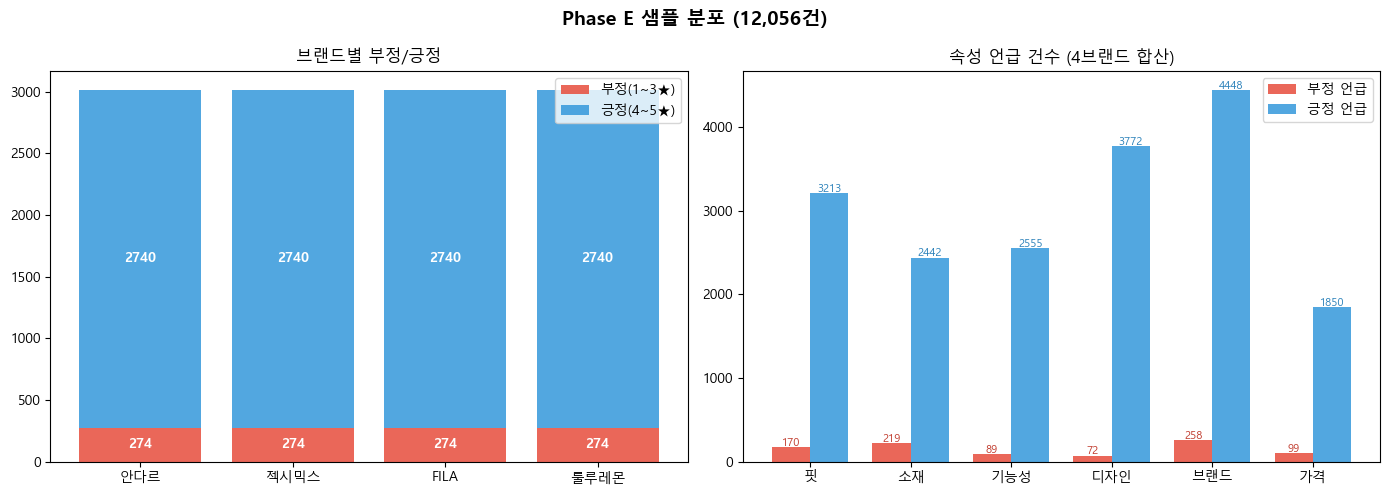

✓ 저장: phase_e_sample_distribution.png


In [1]:
## Phase E-1 분포 확인 — 샘플 구성 검증
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

sample_df = pd.read_parquet('absa_phase_e_sample.parquet')
brands  = ['안다르', '젝시믹스', 'FILA', '룰루레몬']
ASPECTS = ['핏/사이즈', '소재/내구성', '기능성', '디자인', '브랜드/헤리티지', '가격/가치']

pos_only = sample_df[sample_df['rating'] >= 4]
neg_only = sample_df[sample_df['rating'] <= 3]

# ── 1. 별점 분포 ──────────────────────────────────────────────────
print('=== 별점 분포 ===')
rating_rows = []
for brand in brands:
    bdf = sample_df[sample_df['brand'] == brand]
    row = {'브랜드': brand, '전체': len(bdf)}
    for r in range(1, 6):
        cnt = (bdf['rating'] == r).sum()
        row[f'{r}★'] = cnt
    rating_rows.append(row)
print(pd.DataFrame(rating_rows).set_index('브랜드').to_string())

# ── 2. 긍정 속성 언급 비율 ──────────────────────────────────────────
print()
print('=== 긍정 샘플: 속성 언급 비율 (브랜드별, 태깅있는 리뷰 중) ===')
ratio_rows = []
for brand in brands:
    bdf = pos_only[pos_only['brand'] == brand]
    tagged = bdf[bdf['pos_aspects'] != '']
    n = len(tagged) if len(tagged) > 0 else 1
    row = {'브랜드': brand, '태깅있음': len(tagged)}
    for asp in ASPECTS:
        cnt = tagged['pos_aspects'].str.contains(asp, regex=False).sum()
        row[asp] = f'{cnt/n*100:.0f}%'
    ratio_rows.append(row)
print(pd.DataFrame(ratio_rows).set_index('브랜드').to_string())

# ── 3. 부정 속성 언급 비율 ──────────────────────────────────────────
print()
print('=== 부정 샘플: 속성 언급 비율 (브랜드별, 태깅있는 리뷰 중) ===')
neg_ratio_rows = []
for brand in brands:
    bdf = neg_only[neg_only['brand'] == brand]
    tagged = bdf[bdf['neg_aspects'] != '']
    n = len(tagged) if len(tagged) > 0 else 1
    row = {'브랜드': brand, '태깅있음': len(tagged)}
    for asp in ASPECTS:
        cnt = tagged['neg_aspects'].str.contains(asp, regex=False).sum()
        row[asp] = f'{cnt/n*100:.0f}%'
    neg_ratio_rows.append(row)
print(pd.DataFrame(neg_ratio_rows).set_index('브랜드').to_string())

# ── 4. 시각화 ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phase E 샘플 분포 (12,056건)', fontsize=14, fontweight='bold')

# 왼쪽: 브랜드별 부정/긍정
x = range(len(brands))
neg_counts = [(sample_df[sample_df['brand'] == b]['rating'] <= 3).sum() for b in brands]
pos_counts = [(sample_df[sample_df['brand'] == b]['rating'] >= 4).sum() for b in brands]

axes[0].bar(x, neg_counts, label='부정(1~3★)', color='#e74c3c', alpha=0.85)
axes[0].bar(x, pos_counts, bottom=neg_counts, label='긍정(4~5★)', color='#3498db', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(brands)
axes[0].set_title('브랜드별 부정/긍정')
axes[0].legend()
for i, (n, p) in enumerate(zip(neg_counts, pos_counts)):
    axes[0].text(i, n/2, str(n), ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    axes[0].text(i, n + p/2, str(p), ha='center', va='center', color='white', fontsize=10, fontweight='bold')

# 오른쪽: 속성 언급 건수 (부정 vs 긍정, 4브랜드 합산)
asp_neg = [neg_only['neg_aspects'].str.contains(a, regex=False).sum() for a in ASPECTS]
asp_pos = [pos_only['pos_aspects'].str.contains(a, regex=False).sum() for a in ASPECTS]
short_labels = ['핏', '소재', '기능성', '디자인', '브랜드', '가격']
xp = np.arange(len(ASPECTS))
w = 0.38
axes[1].bar(xp - w/2, asp_neg, w, color='#e74c3c', alpha=0.85, label='부정 언급')
axes[1].bar(xp + w/2, asp_pos, w, color='#3498db', alpha=0.85, label='긍정 언급')
axes[1].set_xticks(xp)
axes[1].set_xticklabels(short_labels)
axes[1].set_title('속성 언급 건수 (4브랜드 합산)')
axes[1].legend()
for i, (n, p) in enumerate(zip(asp_neg, asp_pos)):
    axes[1].text(i - w/2, n + 15, str(n), ha='center', fontsize=8, color='#c0392b')
    axes[1].text(i + w/2, p + 15, str(p), ha='center', fontsize=8, color='#2980b9')

plt.tight_layout()
plt.savefig('phase_e_sample_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ 저장: phase_e_sample_distribution.png')

## 추론 모델링 실행코드

In [ ]:
## Phase E-2. ABSA 추론 (v9) — absa_phase_e_sample.parquet → absa_phase_e_predictions.parquet
# 중단 시 absa_phase_e_checkpoint.csv에서 자동 이어받기 (50건마다 저장)

import importlib, sys, ctypes, pandas as pd
sys.path.insert(0, '.')
import absa_v9 as absa
importlib.reload(absa)

# ── Windows 절전/화면끄기 방지 ────────────────────────────────────────
ES_CONTINUOUS       = 0x80000000
ES_SYSTEM_REQUIRED  = 0x00000001
ES_DISPLAY_REQUIRED = 0x00000002
ctypes.windll.kernel32.SetThreadExecutionState(
    ES_CONTINUOUS | ES_SYSTEM_REQUIRED | ES_DISPLAY_REQUIRED
)
print('절전 방지 ON')

try:
    sample_df = pd.read_parquet('absa_phase_e_sample.parquet')
    print(f'추론 대상: {len(sample_df):,}건')
    print(sample_df.groupby('brand').size().rename('건수'))

    pred_full = absa.predict_dataframe(
        sample_df,
        few_shots={},
        checkpoint_path='absa_phase_e_checkpoint.csv',
        golden_path='absa_golden_set_1000_v23.xlsx',
        workers=2,
    )
    pred_full.to_parquet('absa_phase_e_predictions.parquet', index=False)
    print(f'\n✓ 저장: absa_phase_e_predictions.parquet ({len(pred_full):,}건)')

finally:
    # 추론 완료 또는 에러 시 절전 방지 해제
    ctypes.windll.kernel32.SetThreadExecutionState(ES_CONTINUOUS)
    print('절전 방지 OFF')


절전 방지 ON
추론 대상: 12,056건
brand
FILA    3014
룰루레몬    3014
안다르     3014
젝시믹스    3014
Name: 건수, dtype: int64
[v5] tokens 컬럼 없음 → KiWi 토크나이저로 자동 생성 중...
  완료: 1000건
[체크포인트 복구] 100건 이어받기 — 남은 11,956건 계속


추론(v9-핏규칙강화):   5%|▍         | 588/11956 [1:25:57<33:22:05, 10.57s/it]